In [1]:
!pip install --upgrade pip --quiet

In [2]:
!pip install --upgrade numpy --quiet

In [3]:
!pip install --upgrade pandas --quiet

In [4]:
!pip install --upgrade scipy --quiet

In [5]:
!pip install --upgrade statsmodels --quiet

In [6]:
!pip install --upgrade linearmodels --quiet

In [7]:
!pip install --upgrade matplotlib --quiet

In [8]:
!pip install --upgrade seaborn --quiet

In [9]:
import numpy as np

In [10]:
import pandas as pd

In [11]:
import matplotlib.pyplot as plt

In [12]:
import seaborn as sns

In [13]:
import statsmodels.formula.api as smf

In [14]:
from statsmodels.stats.power import TTestIndPower

In [15]:
from linearmodels.iv import IV2SLS

In [16]:
from scipy import stats

In [17]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [18]:
def diferenca_de_medias(dados, tratamento, resultado):
    """Diferença simples de médias entre tratados e controles."""
    g = dados.groupby(tratamento)[resultado].agg(["count", "mean"])
    dif = g.loc[1, "mean"] - g.loc[0, "mean"]
    return g, dif

In [19]:
def balanco_covariaveis(dados, tratamento, covariaveis):
    """Compara a média das covariáveis entre tratados e controles."""
    linhas = []
    for v in covariaveis:
        m1 = dados.loc[dados[tratamento] == 1, v].mean()
        m0 = dados.loc[dados[tratamento] == 0, v].mean()
        linhas.append({"covariável": v, "tratados": m1,
                       "controles": m0, "diferença": m1 - m0})
    return pd.DataFrame(linhas)

In [20]:
def icc_oneway(dados, grupo, variavel):
    """Correlação intraclasse (ICC) de uma variável por meio de ANOVA one-way."""
    d = dados.dropna(subset=[variavel])
    grande = d[variavel].mean()
    ssb = d.groupby(grupo)[variavel].apply(
        lambda x: len(x) * (x.mean() - grande) ** 2).sum()
    ssw = d.groupby(grupo)[variavel].apply(
        lambda x: ((x - x.mean()) ** 2).sum()).sum()
    k = d[grupo].nunique()
    n = len(d)
    n_bar = n / k
    msb = ssb / (k - 1)
    msw = ssw / (n - k)
    icc = (msb - msw) / (msb + (n_bar - 1) * msw)
    return icc, n_bar

In [21]:
# --- animações dos três desenhos de aleatorização (com dados do PROGRESA) ---
_VERMELHO, _AZUL, _CINZA = "#d93636", "#3b78c3", "#cfcfcf"

def anima_aleatorizacao_simples(dados, n=24, colunas=8, seed=7):
    """Aleatorização simples: cada CRIANÇA (folnum) é sorteada individualmente."""
    fol = dados["folnum"].drop_duplicates().sample(n, random_state=seed).values
    pos = [(i % colunas, i // colunas) for i in range(n)]
    rng = np.random.default_rng(seed)
    cor = [_VERMELHO if rng.random() < 0.5 else _AZUL for _ in range(n)]
    fig, ax = plt.subplots(figsize=(8.5, 3.4))
    def update(f):
        ax.clear()
        for i, (x, y) in enumerate(pos):
            c = cor[i] if i < f else _CINZA
            ax.scatter(x, -y, s=320, c=c, edgecolors="white")
            ax.text(x, -y - 0.42, str(fol[i]), ha="center", fontsize=5.5,
                    color="#555")
        ax.set_title(f"Aleatorização simples — {min(f, n)}/{n} crianças "
                     f"(folnum) sorteadas individualmente")
        ax.set_xlim(-1, colunas); ax.set_ylim(-(n // colunas) - 1, 1)
        ax.axis("off")
    anim = FuncAnimation(fig, update, frames=n + 2, interval=320)
    plt.close(fig)
    return HTML(anim.to_jshtml())

def anima_aleatorizacao_estratificada(dados, por_estrato=6, seed=3):
    """Aleatorização estratificada: VILAREJOS (village) sorteados dentro de
    faixas de escolaridade do chefe do domicílio (hohedu)."""
    vil = dados.groupby("village").agg(hohedu_medio=("hohedu", "mean")).reset_index()
    q1, q2 = vil["hohedu_medio"].quantile([1 / 3, 2 / 3])
    vil["estrato"] = pd.cut(vil["hohedu_medio"], bins=[-1, q1, q2, 99],
                            labels=["baixa", "média", "alta"])
    rng = np.random.default_rng(seed)
    estratos = ["baixa", "média", "alta"]
    selecao = {}
    for e in estratos:
        amostra = vil[vil["estrato"] == e].sample(por_estrato, random_state=seed)
        ids = amostra["village"].values
        ordem = list(range(por_estrato)); rng.shuffle(ordem)
        cor = [None] * por_estrato
        for k, j in enumerate(ordem):
            cor[j] = _VERMELHO if k < por_estrato // 2 else _AZUL
        selecao[e] = (ids, cor)
    fig, ax = plt.subplots(figsize=(9, 3.6))
    def update(f):
        ax.clear()
        for s, e in enumerate(estratos):
            ids, cor = selecao[e]
            for i in range(por_estrato):
                c = cor[i] if f > s else _CINZA
                ax.scatter(i, -s, s=340, c=c, edgecolors="white")
                ax.text(i, -s - 0.42, f"v{ids[i]}", ha="center", fontsize=5.5,
                        color="#555")
            ax.text(-1.6, -s, f"hohedu\n{e}", va="center", ha="right",
                    fontsize=8.5)
        ax.set_title("Aleatorização estratificada — vilarejos (village) "
                     "sorteados dentro de cada faixa de escolaridade do chefe")
        ax.set_xlim(-3.6, por_estrato); ax.set_ylim(-3, 1); ax.axis("off")
    anim = FuncAnimation(fig, update, frames=len(estratos) + 2, interval=750)
    plt.close(fig)
    return HTML(anim.to_jshtml())

def anima_aleatorizacao_cluster(dados, n_vilas=6, por_vila=4, seed=5):
    """Aleatorização em cluster: sorteia-se o VILAREJO (village) inteiro;
    todas as crianças dele recebem a mesma designação."""
    vilas = dados["village"].drop_duplicates().sample(n_vilas, random_state=seed).values
    rng = np.random.default_rng(seed)
    cor_vila = [_VERMELHO if rng.random() < 0.5 else _AZUL for _ in range(n_vilas)]
    fig, ax = plt.subplots(figsize=(9, 3.7))
    def update(f):
        ax.clear()
        for v in range(n_vilas):
            c = cor_vila[v] if f > v else _CINZA
            for k in range(por_vila):
                x = (v % 3) * 2 + (k % 2) * 0.5
                y = -(v // 3) * 2 - (k // 2) * 0.5
                ax.scatter(x, y, s=250, c=c, edgecolors="white")
            ax.text((v % 3) * 2 + 0.25, -(v // 3) * 2 + 0.7,
                    f"vila {vilas[v]}", ha="center", fontsize=7.5)
        ax.set_title("Aleatorização em cluster — sorteia-se o vilarejo "
                     "(village) inteiro, com todas as suas crianças")
        ax.set_xlim(-1, 6); ax.set_ylim(-3.5, 1.3); ax.axis("off")
    anim = FuncAnimation(fig, update, frames=n_vilas + 2, interval=750)
    plt.close(fig)
    return HTML(anim.to_jshtml())

# Avaliação de Políticas Públicas com Dados 📊

<p style="text-align: right">Prof. <a href="https://www.linkedin.com/in/heliomacedofilho/">Hélio Bomfim de Macêdo Filho</a><br />
<a href="https://www.idp.edu.br/mestrado/profissional-em-ciencia-de-dados">Mestrado em Administração Pública:<br />Ciência de Dados e Inteligência Artificial no Setor Público</a></p>

## Módulo 02 — Experimentos Aleatorizados

## Sumário
<ul>
    <li>Por que o sorteio resolve o problema 🎲</li>
    <ul>
        <li>Independência entre tratamento e resultados potenciais</li>
        <li>O sorteio zera o viés de seleção</li>
    </ul>
    <li>Como sortear: desenhos de aleatorização 🃏</li>
    <ul>
        <li>Simples, estratificada e em cluster</li>
    </ul>
    <li>Analisando um experimento 📐</li>
    <ul>
        <li>Estimação do efeito, covariáveis e erros-padrão</li>
        <li>Tabela de balanceamento e estimação</li>
        <li>Extra! 🗞️ Teste de aleatorização (Fisher)</li>
    </ul>
    <li>Poder estatístico 🔋</li>
    <ul>
        <li>Erros tipo I e II, MDE, tamanho de amostra</li>
        <li>Aleatorização em cluster e o efeito de desenho</li>
    </ul>
    <li>Quando o experimento não sai como o planejado 🚧</li>
    <ul>
        <li>Não-conformidade, ITT e LATE</li>
    </ul>
    <li>Atrito, ética e validade externa ⚖️</li>
</ul>

👉 Leitura de apoio desta aula (todas gratuitas online):

- FACURE, M. *<a href="https://matheusfacure.github.io/python-causality-handbook/">Causal Inference for the Brave and True</a>*, caps. 2 e 9.
- CUNNINGHAM, S. *<a href="https://mixtape.scunning.com/04-potential_outcomes">Causal Inference: The Mixtape</a>*, cap. 4.
- ANGRIST, J.; PISCHKE, J.-S. *<a href="https://assets.press.princeton.edu/chapters/s10363.pdf">Mastering 'Metrics</a>*, cap. 1.
- DUFLO, E.; GLENNERSTER, R.; KREMER, M. (2007). *<a href="https://www.povertyactionlab.org/sites/default/files/research-paper/Using-Randomization-in-Development-Economics.pdf">Using Randomization in Development Economics Research: A Toolkit</a>*.

🚨 **Antes de começar — arquivo de dados.** 🎲

Usaremos os dados de uma Avaliação do Progresa, 
- programa mexicano de transferência de renda.

Fonte: <a href="https://github.com/vaibhavwalvekar/Econometric-Analysis-Progresa-Mexico">Econometric-Analysis-Progresa-Mexico</a>, 
- baseado em T. Paul Schultz. *<a href="https://www.sciencedirect.com/science/article/abs/pii/S0304387803001858">School subsidies for the poor: evaluating the Mexican Progresa poverty program</a>*, Journal of Development Economics, Volume 74, Issue 1, 2004, Pages 199-250, ISSN 0304-3878.

## Recapitulando o Módulo 01 🔁

👉 No módulo passado, estabelecemos o problema central da inferência causal.

- Cada unidade tem **dois resultados potenciais**:
    - $Y(1)$ com tratamento e
    - $Y(0)$ sem tratamento.
- Só observamos **um** resultado potencial.
- A diferença de médias que calculamos nos dados **não** é o efeito causal:

$$\begin{array}{rcl} 
\underbrace{E[Y\mid D=1] - E[Y\mid D=0]}_{\text{diferença observada}}
& = & \underbrace{E[Y(1)-Y(0)\mid D=1]}_{\text{ATT}}
+ \underbrace{E[Y(0)\mid D=1] - E[Y(0)\mid D=0]}_{\text{viés de seleção}}
\end{array}$$

🚨 O **viés de seleção** aparece: tratados e controles já eram diferentes *antes* do tratamento.

No Bolsa Família, as famílias beneficiárias eram mais pobres
- e isso contaminava a comparação.

👉 A pergunta desta aula:

> Existe alguma forma de **garantir** que o viés de seleção seja zero?

A resposta é **sim** — e é surpreendentemente simples: **sortear** quem recebe
o tratamento.

## Por que o sorteio resolve o problema 🎲

### O fio condutor de hoje: o PROGRESA 🇲🇽

Vamos trabalhar com o **PROGRESA**
- depois rebatizado *Oportunidades*,
- o programa mexicano de transferência condicionada de renda criado em 1997
    - o "avô" do Bolsa Família.

🚨 O PROGRESA tem uma característica que o torna histórico
- ele foi **avaliado por sorteio**.

De 506 vilarejos elegíveis, um sorteio definiu
- **320 vilarejos tratados**
    - (começaram a receber o benefício em 1998) e
- **186 vilarejos de controle**
    - (só entraram no programa cerca de 18 meses depois).

ℹ️ **Para conhecer o programa.** 

O PROGRESA foi rebatizado **Oportunidades** (2002) e depois **Prospera** (2014)

Foi encerrado em 2019.
- A referência institucional mais completa é o balanço de 20 anos do
- CONEVAL (Consejo Nacional de Evaluación de la Política de Desarrollo Social):
- *<a href="https://www.coneval.org.mx/EvaluacionDS/PP/CEIPP/IEPSM/Documents/Libro_POP_20.pdf">El Progresa-Oportunidades-Prospera, a 20 años de su creación</a>* (CONEVAL, 2019).

Para o desenho da avaliação experimental,
- a fonte primária é a série de relatórios do
    - IFPRI (International Food Policy Research Institute),
    - responsável pela avaliação original.

👉 Leia: Skoufias, Emmanuel; McClafferty, Bonnie. 2000. *<a href="https://cgspace.cgiar.org/items/8b71e13e-245e-4281-bedf-58fd487c6214">Is PROGRESA working? summary of the results of an evaluation by IFPRI</a>*. Progresa Report.

👉 Vamos carregar os dados.

In [22]:
progresa = pd.read_csv("data/progresa_completo.csv")
progresa.shape

(77250, 21)

👉 Cada linha é uma **criança** observada em um **ano** (`year` = 97 ou 98).

In [23]:
progresa[["folnum", "year", "village", "progresa", "poor", "sc"]].head()

,folnum,year,village,progresa,poor,sc
0,1,97,163,0,pobre,1.0
1,1,98,163,0,pobre,1.0
2,2,97,163,0,pobre,1.0
3,2,98,163,0,pobre,1.0
4,3,97,163,0,pobre,1.0


Algumas variáveis que vamos usar:

| Coluna | Significado |
|---|---|
| `folnum` | identificador da criança |
| `year` | ano da observação (97 = linha de base; 98 = pós-tratamento) |
| `village` | identificador do vilarejo (a unidade sorteada) |
| `progresa` | vilarejo sorteado para tratamento? (`basal` = sim, `0` = não) |
| `poor` | a família é elegível por renda? (`pobre` / `no pobre`) |
| `sc` | a criança está matriculada na escola? (1 = sim) |
| `sc97` | matrícula na linha de base (1997) |
| `dist_sec` | distância até a escola secundária |
| `hohedu` | anos de escolaridade do chefe do domicílio |
| `fam_n` | número de pessoas na família |
| `indig` | família indígena? (1 = sim) |

👉 Vamos nomear os papéis de cada variável

| Conceito (Módulo 01) | No PROGRESA |
|---|---|
| Unidade de observação | a criança em um ano (`folnum` × `year`) |
| Unidade de análise | a criança em idade escolar |
| Unidade de **aleatorização** | o **vilarejo** (`village`) — é o que foi sorteado |
| Variável de tratamento $D$ | `T` — morar em vilarejo sorteado para o programa |
| Variável de desfecho $Y$ | `sc` — matrícula escolar da criança |
| Covariáveis $X$ | `sc97`, `dist_sec`, `hohedu`, `fam_n`, `indig`... |
| População-alvo | crianças de famílias rurais pobres elegíveis ao programa |
| Amostra | as crianças dos 506 vilarejos da avaliação |

🚨 Repare numa diferença em relação ao Bolsa Família: 
- a **unidade de aleatorização** (o vilarejo) não é a **unidade de análise** (a criança).

Essa distinção vai voltar — é o que torna o desenho um experimento *em cluster*.

👉 Vamos criar duas variáveis numéricas auxiliares, mais fáceis de usar.

In [24]:
# vilarejo tratado
progresa["T"] = (progresa["progresa"] == "basal").astype(int)

In [25]:
# família elegível
progresa["elegivel"] = (progresa["poor"] == "pobre").astype(int)  

In [26]:
progresa[["progresa", "T", "poor", "elegivel"]].head()

,progresa,T,poor,elegivel
0,0,0,pobre,1
1,0,0,pobre,1
2,0,0,pobre,1
3,0,0,pobre,1
4,0,0,pobre,1


### Independência: a mágica do sorteio ✨

👉 Quando o tratamento é **sorteado**, 
- ele não tem relação com nenhuma característica das unidades
- nem com os resultados potenciais.

Matematicamente,

$$\big(Y(0),\, Y(1)\big) \;\perp\; D$$

🚨 Essa independência tem uma consequência decisiva.

Se o tratamento é independente de $Y(0)$, 
- então a média de $Y(0)$ é **igual** nos dois grupos.

$$E[Y(0)\mid D=1] = E[Y(0)\mid D=0]$$

Repare na fórmula do viés de seleção: 
- ela é exatamente a diferença entre esses dois termos. 

Se eles são iguais, **o viés é zero**.

👉 Ademais, sob independência, 
- **somem as distinções entre ATT, ATU e ATE**.

Isto é, $$ATE = ATT = ATU$$

Lembre das definições do Módulo 01:

$$ATE = E[Y(1)-Y(0)]$$

$$ATT = E[Y(1)-Y(0)\mid D=1]$$

$$ATU = E[Y(1)-Y(0)\mid D=0]$$

🚨 A independência $\big(Y(0), Y(1)\big) \perp D$ diz que 
- condicionar em $D$ **não muda** a distribuição dos resultados potenciais.

Logo, a esperança de qualquer função de $Y(0)$ e $Y(1)$
- é a mesma com ou sem o condicionamento:

$$\underbrace{E[Y(1)-Y(0)\mid D=1]}_{ATT} = \underbrace{E[Y(1)-Y(0)\mid D=0]}_{ATU} = \underbrace{E[Y(1)-Y(0)]}_{ATE}$$

👉 Ou seja, $ATT = ATU = ATE$. 

O efeito sobre os 
- tratados, não-tratados e a população inteira **coincidem** porque
    - sob sorteio, tratados e controles são amostras da *mesma* população.

ℹ️ Num estudo observacional isso quase nunca vale: 
- lá os três podem diferir bastante, e
- escolher qual estimar é uma decisão importante.

### Vendo o sorteio funcionar 👁️

👉 Vamos *demonstrar* isso com uma simulação 
- criando uma população onde **conhecemos a verdade**,
- e os dois resultados potenciais de cada unidade.

👉 Pense num paralelo com o PROGRESA: 
- $X$ é a **renda** da família (característica de fundo);
- $Y(0)$ é a **frequência escolar sem** o programa;
- $Y(1)$, a frequência **com** o programa.

🚨 A renda $X$ afeta **tanto** a chance de entrar no programa **quanto** a frequência
- é o confundidor do Módulo 01.

👉 Numa simulação controlada sabemos disso porque nós mesmos construímos os dados.

In [27]:
np.random.seed(42)
n = 10_000

# X é uma característica de fundo (ex.: renda da família)
X = np.random.normal(50, 10, n)

# resultados potenciais: quem tem X menor tem Y0 e Y1 menores
Y0 = 0.5 * X + np.random.normal(0, 5, n)
Y1 = Y0 + 8.0                       # efeito causal verdadeiro = 8, igual p/ todos

pop = pd.DataFrame({"X": X, "Y0": Y0, "Y1": Y1})

In [28]:
pop.head()

,X,Y0,Y1
0,54.967142,24.091097,32.091097
1,48.617357,22.781181,30.781181
2,56.476885,25.251537,33.251537
3,65.230299,33.167240,41.167240
4,47.658466,29.815126,37.815126


In [29]:
print("Efeito causal médio VERDADEIRO (ATE):", 
      round((pop["Y1"] - pop["Y0"]).mean(), 2))

Efeito causal médio VERDADEIRO (ATE): 8.0


👉 **Cenário 1 — atribuição por auto-seleção.** 

Quem tem renda menor "escolhe" entrar no programa
- (como acontece num programa social real).

In [30]:
pop["D_selecao"] = (pop["X"] < pop["X"].median()).astype(int)
pop["Y_selecao"] = np.where(pop["D_selecao"] == 1, pop["Y1"], pop["Y0"])

In [31]:
g, dif = diferenca_de_medias(pop, "D_selecao", "Y_selecao")

In [32]:
g

,count,mean
D_selecao,,
0,5000,28.984840
1,5000,29.129141


In [33]:
print("Diferença de médias (auto-seleção):", round(dif, 2))

Diferença de médias (auto-seleção): 0.14


In [34]:
print("Efeito verdadeiro: 8.00")

Efeito verdadeiro: 8.00


🚨 A diferença de médias dá um número **completamente errado** 
- pode até ficar negativa. O viés de seleção engole o efeito.

👉 **Cenário 2 — atribuição por sorteio.**

Agora um sorteio decide quem entra, sem olhar para `X`.

In [35]:
pop["D_sorteio"] = np.random.binomial(1, 0.5, n)
pop["Y_sorteio"] = np.where(pop["D_sorteio"] == 1, pop["Y1"], pop["Y0"])

In [36]:
g, dif = diferenca_de_medias(pop, "D_sorteio", "Y_sorteio")

In [37]:
g

,count,mean
D_sorteio,,
0,5043,25.061816
1,4957,33.052081


In [38]:
print("Diferença de médias (sorteio):", round(dif, 2))

Diferença de médias (sorteio): 7.99


In [39]:
print("Efeito verdadeiro: 8.00")

Efeito verdadeiro: 8.00


ℹ️ Com o sorteio, a diferença de médias **acerta** o efeito verdadeiro
- sem precisar de nenhum modelo, nenhum controle.

👉 Por quê? Porque o sorteio equilibra `X` entre os grupos. Vamos ver.

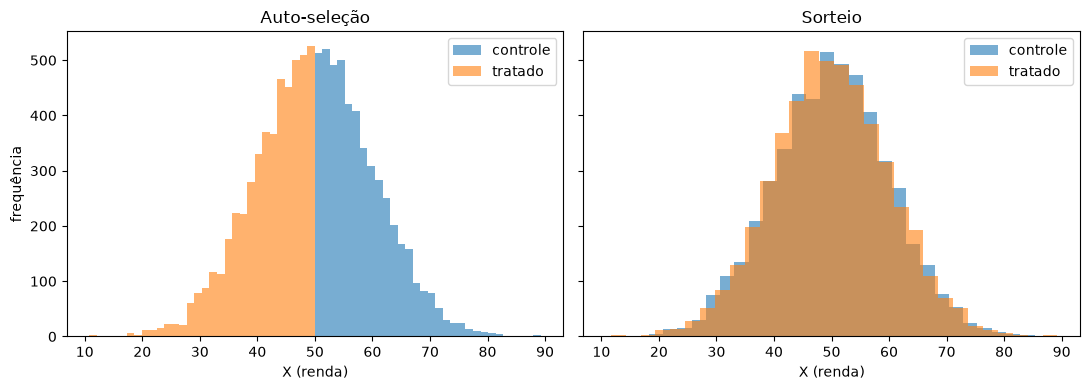

In [40]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, (col, titulo) in zip(eixos, [("D_selecao", "Auto-seleção"),
                                     ("D_sorteio", "Sorteio")]):
    for grupo, rotulo in [(0, "controle"), (1, "tratado")]:
        ax.hist(pop.loc[pop[col] == grupo, "X"], bins=30, alpha=0.6, label=rotulo)
    ax.set_title(titulo)
    ax.set_xlabel("X (renda)")
    ax.legend()

eixos[0].set_ylabel("frequência")
plt.tight_layout();

🚨 O sorteio não "corrige" o viés depois — ele **impede** o viés de nascer.
- À esquerda, tratados e controles têm distribuições de renda **completamente diferentes**. 
- À direita, são **idênticas**.



## Como sortear: desenhos de aleatorização 🃏

👉 "Sortear" não é uma coisa só. 

Há três desenhos principais, e a escolha tem consequências.

### 1. Aleatorização simples 🪙

Cada unidade é designada ao tratamento por um "cara ou coroa"
independente.

- ✅ Simples de implementar e de explicar.
- ⛔ Em amostras pequenas, o acaso pode gerar grupos desbalanceados.

In [41]:
def aleatorizacao_simples(dados, p=0.5, seed=None):
    """Sorteia cada unidade independentemente."""
    rng = np.random.default_rng(seed)
    return rng.binomial(1, p, size=len(dados))

👉 Veja a aleatorização simples em ação
- cada unidade recebe sua cor (🔴 tratado / 🔵 controle) por um sorteio individual e independente.

In [42]:
anima_aleatorizacao_simples(progresa)

ℹ️ **No contexto do PROGRESA:**

Cada ponto é uma **criança**, identificada pelo seu `folnum`. 

A aleatorização simples sortearia criança por criança
- uma recebe a bolsa, sua vizinha de carteira não. 

👉 Na prática isso seria inviável (e geraria contaminação entre vizinhos), 
- mas é o desenho conceitualmente mais simples.

### 2. Aleatorização estratificada (em blocos) 🧱

A amostra é dividida em **estratos** (blocos) por características pré-tratamento, e
- o sorteio é feito **dentro** de cada estrato.

    - ✅ Garante balanceamento nas variáveis usadas para estratificar.
    - ✅ Aumenta a precisão (poder) da estimativa.
    - ✅ Permite analisar subgrupos com segurança.

In [43]:
def aleatorizacao_estratificada(dados, coluna_estrato, p=0.5, seed=None):
    """Sorteia dentro de cada estrato."""
    rng = np.random.default_rng(seed)
    designacao = np.zeros(len(dados), dtype=int)
    for _, idx in dados.groupby(coluna_estrato).groups.items():
        idx = np.array(idx)
        designacao[dados.index.get_indexer(idx)] = rng.binomial(1, p, size=len(idx))
    return designacao

👉 Veja a aleatorização estratificada
- o sorteio acontece **dentro de cada estrato**,
    - garantindo metade tratada e metade controle em todos eles.

In [44]:
anima_aleatorizacao_estratificada(progresa)

ℹ️ **No contexto do PROGRESA:** 

Aqui os **vilarejos** (`village`) são agrupados 
- em três faixas pela **escolaridade média do chefe do domicílio** (`hohedu`)
    - baixa, média e alta
— e o sorteio ocorre **dentro de cada faixa**. 

👉 Assim garantimos que vilarejos de baixa escolaridade 
- apareçam em proporção igual nos grupos de tratamento e controle,
- em vez de deixar isso ao acaso.

🚨 Note que o sorteio continua sendo de **vilarejos** (não de crianças): 
- a estratificação é uma camada que se *soma* à aleatorização em cluster.

### 3. Aleatorização em cluster 🏘️

O sorteio é feito sobre **grupos** (escolas, vilarejos, municípios), 
- não sobre indivíduos.

Todos os indivíduos de um cluster recebem a mesma designação.

- ✅ Necessária quando a intervenção é coletiva, ou para evitar contaminação
  entre vizinhos.
- ⛔ **Reduz o poder estatístico** — voltaremos a isso no bloco de poder.

In [45]:
def aleatorizacao_cluster(dados, coluna_cluster, p=0.5, seed=None):
    """Sorteia clusters inteiros."""
    rng = np.random.default_rng(seed)
    clusters = dados[coluna_cluster].unique()
    tratados = set(clusters[rng.binomial(1, p, size=len(clusters)) == 1])
    return dados[coluna_cluster].isin(tratados).astype(int).values

👉 Veja a aleatorização em cluster
- o sorteio é feito por **grupo**
    - todas as crianças de um vilarejo recebem a mesma cor de uma vez.

In [46]:
anima_aleatorizacao_cluster(progresa)

ℹ️ **No contexto do PROGRESA:** 

O sorteio definiu **vilarejos** (`village`) tratados e de controle; 
- todas as crianças de um vilarejo tratado passaram a ter acesso ao programa.

Isso é prático (o programa chega à comunidade inteira) e
- evita que vizinhos tratados e não-tratados se misturem
- mas, como veremos no bloco de poder,
- cobra um preço estatístico.

🚨 **O PROGRESA usou aleatorização em cluster.**

O sorteio foi feito por **vilarejo**, não por família.

👉 Vamos confirmar isso nos dados: dentro de cada vilarejo, 
- o tratamento deve ser constante.

In [47]:
variacao = progresa.groupby("village").\
    agg({"T": ['count', 'unique']}).\
    rename(columns={'count': 'criancas', 'unique': 'T?'})

In [48]:
variacao.head()

T     
        criancas   T?
village              
1            332  [1]
2            144  [1]
3             70  [0]
4            804  [1]
5            250  [1]

In [49]:
print("Vilarejos no total:", len(variacao.index))

Vilarejos no total: 505


In [50]:
print("Vilarejos com tratamento igual para todas as crianças:",
      int((variacao[('T', 'T?')].apply(len).eq(1)).sum()))

Vilarejos com tratamento igual para todas as crianças: 505


ℹ️ Todos os vilarejos têm tratamento constante 
- confirmando o desenho em cluster. 

O vilarejo é a **unidade de aleatorização**; 
- a criança é a **unidade de análise**.

## Analisando um experimento 📐

👉 Vamos estimar o efeito do PROGRESA sobre a **matrícula escolar**.

Foco nas crianças de **famílias elegíveis**, 
- no ano **pós-tratamento (1998)**.

In [51]:
dados98 = progresa[(progresa["year"] == 98) &
                   (progresa["elegivel"] == 1) &
                   (progresa["sc"].notna())].copy()

In [52]:
dados98.head()

,year,sex,indig,dist_sec,sc,grc,fam_n,min_dist,dist_cap,poor,...,welfare_index,hohsex,hohage,age,village,folnum,grc97,sc97,T,elegivel
1,98,0.0,0.0,4.473,1.0,8.0,7,21.168384,21.168384,pobre,...,583.00000,1.0,35.0,14,163,1,7,1.0,0,1
3,98,1.0,0.0,4.473,1.0,7.0,7,21.168384,21.168384,pobre,...,583.00000,1.0,35.0,13,163,2,6,1.0,0,1
5,98,0.0,0.0,4.473,1.0,3.0,7,21.168384,21.168384,pobre,...,583.00000,1.0,35.0,9,163,3,2,1.0,0,1
7,98,0.0,0.0,3.154,0.0,6.0,6,127.114780,154.196003,pobre,...,684.00000,1.0,85.0,15,271,4,6,0.0,1,1
9,98,1.0,0.0,3.373,1.0,2.0,5,85.300272,105.878669,pobre,...,742.14001,1.0,26.0,10,263,5,2,1.0,1,1


In [53]:
print("Crianças na análise:", len(dados98))

Crianças na análise: 27450


### A tabela de balanceamento ⚖️

👉 Antes de estimar qualquer efeito: o sorteio funcionou? 
- Os grupos são comparáveis na **linha de base (1997)**?

Esta é a **tabela de balanceamento** 
- o primeiro diagnóstico de todo RCT.

In [54]:
base97 = progresa[(progresa["year"] == 97) &
                  (progresa["elegivel"] == 1)].copy()

In [55]:
base97.head()

,year,sex,indig,dist_sec,sc,grc,fam_n,min_dist,dist_cap,poor,...,welfare_index,hohsex,hohage,age,village,folnum,grc97,sc97,T,elegivel
0,97,0.0,0.0,4.473,1.0,7.0,7,21.168384,21.168384,pobre,...,583.00000,1.0,35.0,13,163,1,7,1.0,0,1
2,97,1.0,0.0,4.473,1.0,6.0,7,21.168384,21.168384,pobre,...,583.00000,1.0,35.0,12,163,2,6,1.0,0,1
4,97,0.0,0.0,4.473,1.0,2.0,7,21.168384,21.168384,pobre,...,583.00000,1.0,35.0,8,163,3,2,1.0,0,1
6,97,0.0,0.0,3.154,0.0,6.0,6,127.114780,154.196003,pobre,...,684.00000,1.0,85.0,14,271,4,6,0.0,1,1
8,97,1.0,0.0,3.373,1.0,2.0,5,85.300272,105.878669,pobre,...,742.14001,1.0,26.0,9,263,5,2,1.0,1,1


In [56]:
balanco_covariaveis(base97, "T",
                    ["sc97", "dist_sec", "hohedu", "fam_n", "age", "indig"])

,covariável,tratados,controles,diferença
0,sc97,0.822697,0.815186,0.007511
1,dist_sec,2.453122,2.507662,-0.054540
2,hohedu,2.663139,2.590348,0.072791
3,fam_n,7.281327,7.302469,-0.021142
4,age,10.716991,10.742023,-0.025032
5,indig,0.325986,0.332207,-0.006222


ℹ️ Todas as diferenças são minúsculas. 
- Tratados e controles são praticamente idênticos antes do programa 
    - como esperado sob aleatorização.

🚨 Repare: as diferenças não são *exatamente* zero. 
- O sorteio equilibra os grupos em termos **estatísticos**, não matemáticos. 
- Pequenas diferenças por acaso são normais.

### Estimando o efeito 🎯

👉 Primeiro, a diferença simples de médias na matrícula.

In [57]:
tabela, efeito = diferenca_de_medias(dados98, "T", "sc")

In [58]:
tabela

,count,mean
T,,
0,10423,0.807637
1,17027,0.846479


In [59]:
print("Efeito estimado (diferença de médias):", round(efeito, 4))

Efeito estimado (diferença de médias): 0.0388


👉 O PROGRESA aumentou a matrícula em cerca de **+3,9 pontos percentuais**.

Diferente do Módulo 01, aqui podemos **ler isso como efeito causal** 
- porque o tratamento foi sorteado.

### O mesmo número, via regressão 📈

👉 A regressão de `sc` em `T` dá exatamente a mesma estimativa de ponto.

In [60]:
modelo = smf.ols("sc ~ T", data=dados98).fit()

In [61]:
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     sc   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     69.87
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           6.64e-17
Time:                        12:56:12   Log-Likelihood:                -11926.
No. Observations:               27450   AIC:                         2.386e+04
Df Residuals:                   27448   BIC:                         2.387e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8076      0.004    220.676      0.000       0.800       0.815
T              0.0388      0.005      8.359      0.000       0.030       0.048
==============================================================================
Omnibus:                     7638.939   Durbin-Watson:                   1.734
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            15767.534
Skew:                          -1.767   Prob(JB):                         0.00
Kurtosis:                       4.140   Cond. No.                         3.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [62]:
print("Coeficiente de T:", round(modelo.params["T"], 4))

Coeficiente de T: 0.0388


In [63]:
print("Erro-padrão de T:", modelo.bse["T"])

Erro-padrão de T: 0.004646903117748092


🚨 **Mas o erro-padrão precisa de cuidado.** 

Como o sorteio foi por vilarejo, 
- as crianças de um mesmo vilarejo não são observações independentes.

Ignorar isso **subestima** o erro-padrão. 
- A correção é agrupar (*cluster*) os erros-padrão por vilarejo.

In [64]:
modelo_cluster = smf.ols("sc ~ T", data=dados98).fit(
    cov_type="cluster", cov_kwds={"groups": dados98["village"]})

In [65]:
pd.DataFrame({
    "erro-padrão": ["ingênuo (sem cluster)", "agrupado por vilarejo"],
    "valor": [modelo.bse["T"], modelo_cluster.bse["T"]],
})

,erro-padrão,valor
0,ingênuo (sem cluster),0.004647
1,agrupado por vilarejo,0.010359


ℹ️ O erro-padrão correto (agrupado) é **maior**.

Levar a estrutura de cluster a sério nos deixa apropriadamente mais cautelosos.

### Covariáveis: mais precisão, sem viés 🔧

👉 Num RCT, 
- incluir covariáveis pré-tratamento **não corrige viés**,
    - (não há viés a corrigir, graças ao sorteio).
- mas elas **reduzem o ruído** e
    - tornam a estimativa mais precisa.

In [66]:
dados98_cov = dados98.dropna(subset=["sc97", "dist_sec", "indig"]).copy()

In [67]:
modelo_cov = smf.ols("sc ~ T + sc97 + dist_sec + hohedu + fam_n + indig",
                     data=dados98_cov).fit(cov_type="cluster", 
                                           cov_kwds={"groups": dados98_cov["village"]})

In [68]:
modelo_cov.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     sc   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     980.2
Date:                Sat, 25 Jul 2026   Prob (F-statistic):          3.47e-274
Time:                        12:56:12   Log-Likelihood:                -4950.1
No. Observations:               26299   AIC:                             9914.
Df Residuals:                   26292   BIC:                             9971.
Df Model:                           6                                         
Covariance Type:              cluster                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2189      0.013     17.447      0.000       0.194       0.244
T              0.0355      0.006      5.748      0.000       0.023       0.048
sc97           0.6700      0.009     72.693      0.000       0.652       0.688
dist_sec      -0.0043      0.001     -2.870      0.004      -0.007      -0.001
hohedu         0.0075      0.001      9.632      0.000       0.006       0.009
fam_n         -0.0008      0.001     -0.813      0.416      -0.003       0.001
indig          0.0177      0.006      2.948      0.003       0.006       0.030
==============================================================================
Omnibus:                     8605.343   Durbin-Watson:                   1.779
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            37088.512
Skew:                          -1.561   Prob(JB):                         0.00
Kurtosis:                       7.909   Cond. No.                         44.7
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [69]:
pd.DataFrame({
    "modelo": ["sc ~ T", "sc ~ T + covariáveis"],
    "efeito de T": [modelo_cluster.params["T"], modelo_cov.params["T"]],
    "erro-padrão": [modelo_cluster.bse["T"], modelo_cov.bse["T"]],
})

,modelo,efeito de T,erro-padrão
0,sc ~ T,0.038842,0.010359
1,sc ~ T + covariáveis,0.035475,0.006171


ℹ️ O efeito estimado mal se move, 
- mas o erro-padrão **encolhe**: ganho de precisão de graça.

👉 Por que escolhemos `sc97`, `dist_sec`, `hohedu`, `fam_n` e `indig`?

Primeiro, todas são **medidas antes do programa** (ou fixas no tempo):
- `sc97` é a matrícula em 1997 (linha de base);
- `indig` (família indígena) é uma característica estrutural;
- `dist_sec`, `hohedu` e `fam_n` descrevem o domicílio na linha de base.

Segundo, todas são **boas preditoras da matrícula** 
- e é isso que reduz o ruído residual e aperta o erro-padrão.

🚨 **Por que covariáveis medidas *depois* do programa são maus controles?** 

Porque o tratamento pode ter **afetado** essas variáveis.

Voltando à linguagem do Módulo 01:

- Uma variável pós-tratamento influenciada por $D$ é
    - um **mediador** (está no caminho causal $D \rightarrow \text{variável} \rightarrow Y$); e
    - controlá-la **bloqueia** parte do efeito que queremos medir.

- Se a variável é influenciada por $D$ **e** por outra causa de $Y$,
    - ela é um **colisor**; e
    - controlá-la **abre** um caminho espúrio e cria viés.

👉 Em ambos os casos o controle é prejudicial. 

Por isso a regra: num RCT, só entram covariáveis **pré-tratamento** 
- elas não podem ter sido afetadas pelo tratamento,
    - porque vieram antes dele.

ℹ️ Exemplo concreto no PROGRESA: 

Usar a *renda da família em 1998* como covariável seria um erro 
- o programa é uma transferência de renda,
    - então a renda de 1998 é um **mediador**.
- já a renda de 1997 (pré-tratamento) seria aceitável.

### Extra! 🗞️ O teste de aleatorização (Fisher) 🔀

O efeito do PROGRESA já foi estabelecido na seção anterior; 
- o que vem abaixo é uma forma alternativa e elegante de chegar à mesma conclusão,
- sem supor fórmulas de erro-padrão.

👉 Há uma forma de inferência que não depende de nenhuma fórmula de erro-padrão: 
- o **teste de aleatorização** (ou teste de permutação),
    - proposto por Fisher.

💡 A ideia: 
- se o tratamento não tem efeito nenhum,
    - então o rótulo "tratado" é arbitrário.
- Podemos **re-sortear** os rótulos milhares de vezes; e
    - ver onde o efeito observado cai nessa distribuição.

🚨 Como o sorteio real foi por vilarejo, o **re-sorteio também precisa ser por vilarejo**.

In [70]:
def teste_aleatorizacao(dados, n_simulacoes=1000, seed=42):
    """Re-sorteia o tratamento por vilarejo e recalcula o efeito."""
    rng = np.random.default_rng(seed)
    villages = dados["village"].unique()
    p_trat = dados.groupby("village")["T"].first().mean()

    efeito_obs = (dados.loc[dados["T"] == 1, "sc"].mean()
                  - dados.loc[dados["T"] == 0, "sc"].mean())

    efeitos_simulados = []
    for _ in range(n_simulacoes):
        trat = set(villages[rng.binomial(1, p_trat, len(villages)) == 1])
        t_sim = dados["village"].isin(trat)
        ef = dados.loc[t_sim, "sc"].mean() - dados.loc[~t_sim, "sc"].mean()
        efeitos_simulados.append(ef)

    return efeito_obs, np.array(efeitos_simulados)

In [71]:
efeito_obs, efeitos_sim = teste_aleatorizacao(dados98)

p_valor = np.mean(np.abs(efeitos_sim) >= np.abs(efeito_obs))

In [72]:
print("Efeito observado:", round(efeito_obs, 4))

Efeito observado: 0.0388


In [73]:
print("p-valor do teste de aleatorização:", round(p_valor, 4))

p-valor do teste de aleatorização: 0.0


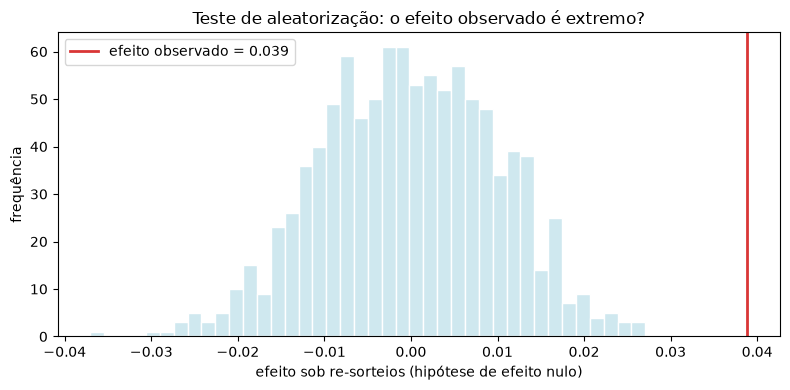

In [74]:
plt.figure(figsize=(8, 4))
plt.hist(efeitos_sim, bins=40, color="#cfe8ef", edgecolor="white")
plt.axvline(efeito_obs, color="#d93636", lw=2,
            label=f"efeito observado = {efeito_obs:.3f}")
plt.xlabel("efeito sob re-sorteios (hipótese de efeito nulo)")
plt.ylabel("frequência")
plt.title("Teste de aleatorização: o efeito observado é extremo?")
plt.legend()
plt.tight_layout();

ℹ️ O efeito observado fica bem na cauda da distribuição de "efeitos por acaso" 
- evidência de que o PROGRESA teve, sim, efeito sobre a matrícula.

👉 Repare: chegamos à mesma conclusão da regressão, 
- mas **sem supor nenhuma fórmula**
    - só o próprio mecanismo de sorteio.

## Wrap-up ☕

👉 Até aqui: o sorteio identifica o efeito, e sabemos analisá-lo.

Na volta: como **planejar** um experimento 
- e o que fazer quando ele não sai como o planejado.

## Poder estatístico 🔋

👉 Imagine que você vai desenhar um RCT.

A pergunta inevitável: 
- **de quantas unidades eu preciso?**

Responder isso é fazer um **cálculo de poder** (estatístico).

### Dois tipos de erro 🎯

Todo teste de hipótese pode errar de duas formas:

| | A política **não** funciona | A política **funciona** |
|---|---|---|
| **Teste diz que funciona** | Erro tipo I (α) | ✅ acerto |
| **Teste diz que não** | ✅ acerto | Erro tipo II (β) |

- **α** (tipo I): "descobrir" um efeito que não existe. Convenção: 5%.
- **β** (tipo II): **não** detectar um efeito que existe.
- **Poder = 1 − β**: a probabilidade de detectar um efeito real. Convenção: 80%.

🚨 Note que 
- $\alpha \leftrightarrow FP$,
- $\beta \leftrightarrow FN$,
- $Poder \leftrightarrow Sensibilidade/Recall$
    - (da Matriz de Contingência de Aprendizado de Máquina.)

### O efeito mínimo detectável (MDE) 📏

👉 Nenhum experimento detecta um efeito *arbitrariamente pequeno*.

Dado o tamanho da amostra, 
- existe um **efeito mínimo detectável** (MDE):
    - o menor efeito que o experimento consegue distinguir de zero
    - com poder de 80%.

Para um experimento de dois braços equilibrados:

$$\text{MDE} = (t_{1-\kappa} + t_{\alpha/2}) \times \sigma \times
\sqrt{\dfrac{1}{p(1-p)\,N}}$$

onde 
- $\sigma$ é o desvio-padrão do resultado,
- $p$ a fração tratada,
- $N$ o tamanho da amostra,
- $\kappa$ o poder e
- $\alpha$ o nível de significância.

🚨 Leia a fórmula: o MDE **cai** com a raiz de $N$. 

Para detectar um efeito **2× menor**, 
- você precisa de **4× mais** amostra.

### Calculando poder em Python 🐍

👉 A biblioteca `statsmodels` calcula poder para teste de médias. 

Quanta amostra para detectar um efeito de 0,1 desvio-padrão?

In [75]:
analise = TTestIndPower()
n_por_grupo = analise.solve_power(
    effect_size=0.10,   # efeito em desvios-padrão (d de Cohen)
    alpha=0.05,
    power=0.80,
    ratio=1.0,
)

In [76]:
print("N necessário por grupo:", round(n_por_grupo))

N necessário por grupo: 1571


In [77]:
print("N total:", round(n_por_grupo) * 2)

N total: 3142


👉 Podemos traçar a **curva de poder**: 
- como o poder cresce com a amostra, para diferentes tamanhos de efeito.

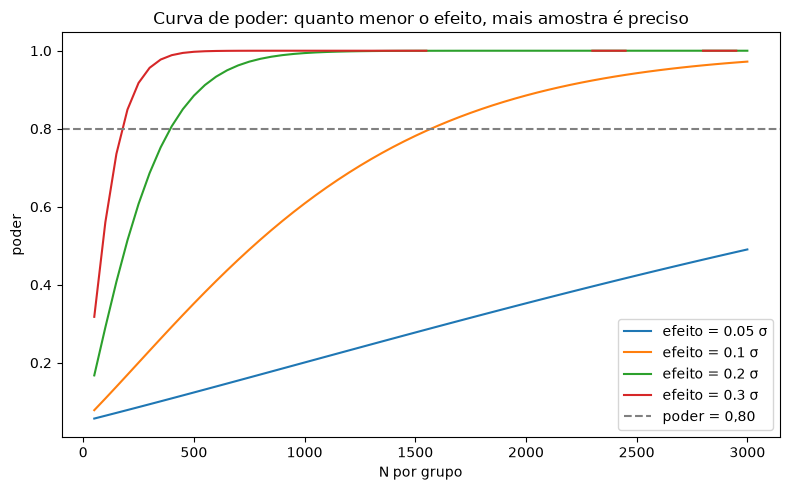

In [78]:
ns = np.arange(50, 3001, 50)
plt.figure(figsize=(8, 5))

for efeito in [0.05, 0.10, 0.20, 0.30]:
    poder = analise.power(effect_size=efeito, nobs1=ns, alpha=0.05,
                          ratio=1.0)
    plt.plot(ns, poder, label=f"efeito = {efeito} σ")

plt.axhline(0.80, color="grey", ls="--", label="poder = 0,80")
plt.xlabel("N por grupo")
plt.ylabel("poder")
plt.title("Curva de poder: quanto menor o efeito, mais amostra é preciso")
plt.legend()
plt.tight_layout();

ℹ️ Para efeitos pequenos (0,05 σ) a curva sobe devagar 
- exige milhares de unidades.

Para efeitos grandes (0,30 σ), 
- algumas centenas bastam.

### Poder por simulação 🎰

👉 Fórmulas existem para casos simples, 
- mas há uma forma mais geral e flexível de calcular poder:
    - **simular** o experimento muitas vezes e contar quantas vezes ele detecta o efeito.

In [79]:
def poder_por_simulacao(n_por_grupo, efeito, sigma=1.0,
                        n_sim=500, alpha=0.05, seed=42):
    """Estima o poder simulando o experimento n_sim vezes."""
    rng = np.random.default_rng(seed)
    rejeicoes = 0
    for _ in range(n_sim):
        controle = rng.normal(0, sigma, n_por_grupo)
        tratado = rng.normal(efeito, sigma, n_por_grupo)
        _, p = stats.ttest_ind(tratado, controle)
        if p < alpha:
            rejeicoes += 1
    return rejeicoes / n_sim

In [80]:
for n in [100, 250, 500, 1000]:
    poder = poder_por_simulacao(n, efeito=0.15)
    print(f"N por grupo = {n:5d}  ->  poder = {poder:.2f}")

N por grupo =   100  ->  poder = 0.20
N por grupo =   250  ->  poder = 0.44
N por grupo =   500  ->  poder = 0.64
N por grupo =  1000  ->  poder = 0.94


ℹ️ A simulação concorda com a fórmula 
- e funciona em situações onde não há fórmula fechada, como veremos a seguir.

### O custo da aleatorização em cluster 🏘️

👉 Quando sorteamos **clusters**, 
- as unidades dentro de um cluster são parecidas entre si.

Elas carregam **informação redundante** — e o poder cai.

A semelhança interna é medida pela **correlação intraclasse (ICC)**, $\rho$.

O **efeito de desenho** (*design effect*) quantifica a perda:

$$\text{DE} = 1 + (\bar{n} - 1)\,\rho$$

onde $\bar{n}$ é o tamanho médio do cluster.

O tamanho de amostra **efetivo** é $\frac{N}{DE}$.

👉 Vamos calcular o ICC da matrícula escolar no PROGRESA, por vilarejo.

In [81]:
icc, n_medio = icc_oneway(base97, "village", "sc")

In [82]:
print("ICC da matrícula (sc) por vilarejo:", round(icc, 4))

ICC da matrícula (sc) por vilarejo: 0.0338


In [83]:
print("Tamanho médio do vilarejo:", round(n_medio, 1))

Tamanho médio do vilarejo: 61.2


In [84]:
design_effect = 1 + (n_medio - 1) * icc

In [85]:
print("Efeito de desenho:", round(design_effect, 2))

Efeito de desenho: 3.04


🚨 Um ICC que parece pequeno (0,03) combinado com vilarejos grandes 
- gera um efeito de desenho de várias vezes.

Na prática:
- uma amostra de $N$ crianças sorteadas por vilarejo "vale", em poder,
- o equivalente a apenas $\frac{N}{DE}$ crianças sorteadas individualmente.

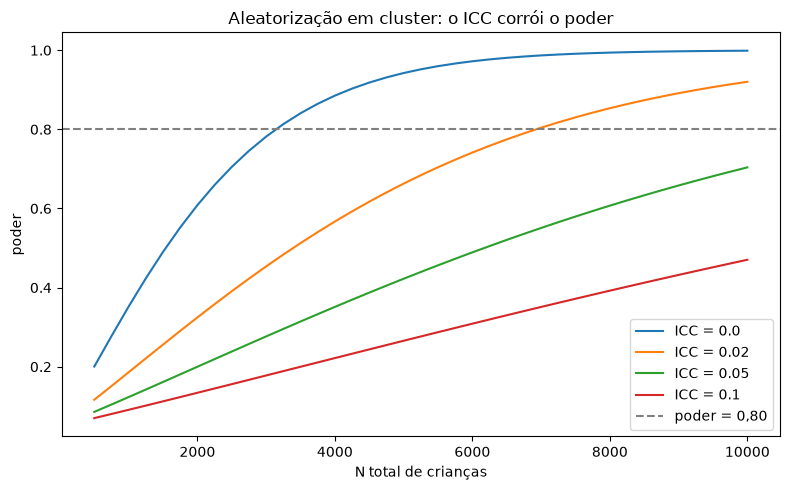

In [86]:
ns_total = np.arange(500, 10001, 250)
plt.figure(figsize=(8, 5))

for rho in [0.0, 0.02, 0.05, 0.10]:
    de = 1 + (n_medio - 1) * rho
    n_efetivo = ns_total / de
    poder = analise.power(effect_size=0.10, nobs1=n_efetivo / 2,
                          alpha=0.05, ratio=1.0)
    plt.plot(ns_total, poder, label=f"ICC = {rho}")

plt.axhline(0.80, color="grey", ls="--", label="poder = 0,80")
plt.xlabel("N total de crianças")
plt.ylabel("poder")
plt.title("Aleatorização em cluster: o ICC corrói o poder")
plt.legend()
plt.tight_layout();

ℹ️ Quanto maior o ICC, mais a curva de poder se desloca para a direita
-  ou seja, mais crianças são necessárias para o mesmo poder.

👉 Por isso,
- experimentos em cluster geralmente precisam de **muito mais** unidades que experimentos individuais.

## Quando o experimento não sai como o planejado

👉 No mundo real, nem todo mundo designado ao tratamento de fato o recebe.

No PROGRESA, uma família podia morar num vilarejo tratado e, 
- ainda assim, **não se inscrever** no programa. 

👉 Isso é **não-conformidade** (*noncompliance*).

### Quem é quem num experimento 👥

👉 Diante de uma designação aleatória, 
- cada unidade tem **dois comportamentos potenciais**:
    - o que ela faz *se for designada ao tratamento*, e
    - o que faz *se for designada ao controle*.

Escrevendo $D(z)$ para "toma ou não o tratamento, quando designada a $z$", 
- cada unidade é descrita por um par $(D(0),\, D(1))$. 

Como cada decisão é binária, há exatamente $2 \times 2 = 4$ combinações possíveis.

| | $D(0)=0$ — não toma se for controle | $D(0)=1$ — toma se for controle |
|---|---|---|
| **$D(1)=1$ — toma se for tratada** | **Conforme** (*complier*) | **Sempre-toma** (*always-taker*) |
| **$D(1)=0$ — não toma se for tratada** | **Nunca-toma** (*never-taker*) | **Desafiante** (*defier*) |

👉 Lendo a tabela:

- **Conforme** — segue a designação: toma se tratada, não toma se controle.
- **Sempre-toma** — toma o tratamento nos dois cenários.
- **Nunca-toma** — não toma em nenhum cenário.
- **Desafiante** — faz o oposto da designação.

ℹ️ Os quatro tipos são **mutuamente exclusivos** e **esgotam as possibilidades**:

Cada unidade tem um único par $(D(0), D(1))$, então 
- cai em exatamente uma célula da tabela e
- a tabela $2\times2$ cobre todos os pares que existem. 

Os quatro tipos formam uma **partição** da população (ℹ️ não há um quinto tipo).

🚨 Mas há um limite, o mesmo do Módulo 01: 
- para cada unidade observamos só **um** dos cenários
- ela foi designada a tratamento *ou* a controle. 

Logo, 
- **não sabemos a que tipo uma unidade individual pertence**;
- conseguimos estimar apenas as **proporções** de cada tipo na população.

### Dois efeitos diferentes

Com não-conformidade, separam-se duas perguntas:

- **ITT** (*Intention-to-Treat*):
    - efeito de **ser designado** ao tratamento.
    - Compara todos os designados com todos os não-designados, *independentemente* de terem aderido.
- **LATE / TOT** (*Local Average Treatment Effect*/*Treatment-On-the-Treated*):
    - efeito de **efetivamente receber** o tratamento, entre os conformes.

👉 Qual usar? Depende da pergunta.

- O **ITT** mede o efeito da **política como ela realmente funciona** (com adesão imperfeita).
    - É o número que um gestor público precisa.
- O **LATE** mede o efeito **do tratamento em si**, sobre quem o recebe.

### Simulando a não-conformidade 🧪

🚨 **Atenção: a partir daqui há um componente simulado.** 

👉 **O que é real e o que falta.** 
- Tudo o que usamos até aqui vem dos microdados do PROGRESA:
    - a designação dos vilarejos (`T`),
    - a matrícula (`sc`),
    - as covariáveis, e
    - o **ITT** que calcularemos é um resultado real.

Mas a base **não registra a adesão individual**: 
- não há como saber quais famílias de fato aderiram ao tratamento.
- E sem adesão **não é possível calcular o LATE com os dados reais**.

ℹ️ **A solução didática: simular a adesão.**

Vamos *construir* uma variável `inscrito` de forma controlada:
- 85% de adesão nos vilarejos tratados,
- 0% nos de controle (não-conformidade unilateral). 

Como **nós** definimos a taxa, conhecemos a "verdade" e 
- podemos checar se o estimador de Wald a recupera
    - (a mesma lógica do colisor sintético do Módulo 01.)

🚨 Consequência para a leitura: o **ITT** abaixo é real; 
- o **LATE** é **ilustrativo**
- depende dos 85% que arbitramos. 

Num estudo real, essa taxa viria dos registros administrativos do programa.

In [87]:
# === COMPONENTE SIMULADO ===
# A base do PROGRESA NÃO traz a adesão individual.
# Construímos "inscrito" de forma controlada, só para fins didáticos:
# 85% de adesão entre os designados; 0% nos vilarejos de controle.
np.random.seed(42)
dados98 = dados98.copy()
dados98["inscrito"] = 0

designados = dados98["T"] == 1
dados98.loc[designados, "inscrito"] = np.random.binomial(
    1, 0.85, size=int(designados.sum()))

taxa_adesao = dados98.loc[designados, "inscrito"].mean()
print("Taxa de adesão entre os designados:", round(taxa_adesao, 3))

Taxa de adesão entre os designados: 0.85


### ITT, adesão e o estimador de Wald 🧮

👉 O **ITT** é a regressão da matrícula na **designação** `T`.

In [88]:
itt = smf.ols("sc ~ T", data=dados98).fit().params["T"]

In [89]:
print("ITT (efeito de ser designado):", round(itt, 4))

ITT (efeito de ser designado): 0.0388


👉 O **LATE** se obtém dividindo o ITT pela taxa de adesão. É o **estimador de Wald**:

$$\text{LATE} = \dfrac{\text{ITT}}{\text{adesão}}$$

In [90]:
late_wald = itt / taxa_adesao

In [91]:
print("LATE (estimador de Wald):", round(late_wald, 4))

LATE (estimador de Wald): 0.0457


ℹ️ O LATE é **maior** que o ITT. 

👉 Faz sentido: 
- o ITT "dilui" o efeito ao incluir os 15% que nunca aderiram
    - (e em quem o programa não pôde agir).

### LATE como variável instrumental 🛠️

👉 Há uma forma mais geral de estimar o LATE:
- tratar a **designação aleatória como um instrumento** para o tratamento recebido.

A designação `T` é um instrumento ideal 
- afeta a adesão,
- é aleatória, e
- só afeta a matrícula *através* da adesão.

In [92]:
dados98["const"] = 1

iv = IV2SLS(dependent=dados98["sc"],
            exog=dados98[["const"]],
            endog=dados98["inscrito"],
            instruments=dados98["T"]).fit()

In [93]:
print("LATE via variável instrumental:", 
      round(iv.params["inscrito"], 4))

LATE via variável instrumental: 0.0457


In [94]:
print("LATE via estimador de Wald:", round(late_wald, 4))

LATE via estimador de Wald: 0.0457


ℹ️ Os dois métodos dão o mesmo número
- são a mesma ideia vista de dois ângulos.

🚨 E o que **não** se deve fazer? 
- comparar diretamente quem se inscreveu (aderiu)
- com quem não se inscreveu (não aderiu). 

Os inscritos se *autosselecionaram* 
- isso traria de volta o viés de seleção do Módulo 01. 

A designação aleatória é o que salva a estimativa.

🚨 **Lembrete final sobre este bloco.** 
- O valor do LATE que obtivemos (≈ 0,046)
    - depende da taxa de adesão simulada de 85%.

O **método** (ir do ITT ao LATE dividindo pela adesão, ou via variável instrumental)
- é real e geral.

👉 Lembre-se que simulamos a adesão, mas 
- em um estudo de verdade,
    - a adesão viria dos registros administrativos do programa.

## Atrito, ética e validade externa ⚖️

### Atrito 📉

👉 **Atrito** (*attrition*) é a perda de unidades entre a linha de base e a medição final
- famílias que mudam,
- recusam responder,
- somem.

O perigo não é a perda em si
- é a perda **diferencial**.

In [95]:
dados98_todos = progresa[(progresa["year"] == 98) &
                        (progresa["elegivel"] == 1)].copy()

dados98_todos["perdido"] = dados98_todos["sc"].isna().astype(int)

In [96]:
print("Atrito total:", f"{dados98_todos["perdido"].mean():.1%}")

Atrito total: 16.0%


In [97]:
print("Atrito por grupo:")
print(dados98_todos.groupby("T")["perdido"].mean().\
    map(lambda x: f"{x:.1%}"))

Atrito por grupo:
T
0    16.4%
1    15.8%
Name: perdido, dtype: str


ℹ️ No PROGRESA o atrito é parecido entre tratados e controles
- **atrito simétrico**.
- Isso é relativamente benigno.

🚨 O problema grave é o **atrito diferencial**: 
- quando tratamento e controle perdem unidades em taxas — ou perfis — diferentes.

Aí os grupos que *sobram* deixam de ser comparáveis, e o sorteio é "desfeito".

👉 Vamos *provocar* atrito diferencial para ver o "estrago".

In [98]:
np.random.seed(42)
simulado = dados98.copy()

# no controle, crianças não-matriculadas tendem a sumir mais
prob_sumir = np.where((simulado["T"] == 0) & (simulado["sc"] == 0), 
                      0.5, 0.05)
simulado["sumiu"] = np.random.binomial(1, prob_sumir)

In [99]:
print("Atrito por grupo:")
print(simulado.groupby("T")["sumiu"].mean().map(lambda x: f"{x:.1%}"))

Atrito por grupo:
T
0    13.8%
1     5.1%
Name: sumiu, dtype: str


In [100]:
efeito_atrito_simetrico = diferenca_de_medias(dados98, "T", "sc")[1]

In [101]:
simulado = simulado[simulado["sumiu"] == 0]
efeito_atrito_diferencial = diferenca_de_medias(simulado, "T", "sc")[1]

In [102]:
pd.DataFrame({
    "amostra": ["real (com atrito simétrico)", 
                "simulada (com atrito diferencial)"],
    "efeito estimado do tratamento": [efeito_atrito_simetrico, 
                                      efeito_atrito_diferencial],
})

,amostra,efeito estimado do tratamento
0,real (com atrito simétrico),0.038842
1,simulada (com atrito diferencial),-0.043893


🚨 O atrito diferencial **enviesa** a estimativa: 
- ao remover seletivamente crianças não-matriculadas do controle,
- o grupo de controle parece melhor do que é,
    - e o efeito do programa é **subestimado**.

ℹ️ **Diagnóstico mínimo de atrito.** 
- Quando há perda de unidades,
    - duas perguntas precisam ser respondidas antes de confiar na estimativa.

**(1) A taxa de atrito é igual entre os grupos?** 
- *quantos* saíram de cada lado?
    - Taxas parecidas → atrito **simétrico**,
        - relativamente benigno.
    - Taxas diferentes → atrito **diferencial**:
        - o tratamento influenciou quem permaneceu, e
        - a comparação deixa de ser confiável.

👉 É a conta `groupby("T")["sumiu"].mean()`.

**(2) O perfil de quem sai é igual entre os grupos?** 
- *quem* saiu de cada lado?

🚨 Mesmo com taxas iguais, pode haver viés: 
- se de um grupo somem os mais pobres e do outro sai gente representativa,
    - os que permanecem deixam de ser comparáveis.

👉 Compara-se características pré-tratamento de quem saiu, ex.: 
- `simulado[simulado["sumiu"]==1].groupby("T")[["sc97","hohedu"]].mean()`.

ℹ️ **Resumo:** 
- o ponto (1) pergunta *quantos* saíram;
- o ponto (2), *quais* saíram. 

O atrito vira problema se a resposta diferir entre os grupos em qualquer uma das duas dimensões.

👉 **E quando a dúvida sobre viés permanece?** 
- Em vez de um único número (possivelmente contaminado),
- reporta-se um **intervalo** que contém o efeito verdadeiro.

Os **bounds de Lee** (Lee, 2009) constroem esse intervalo: 
- descarta-se uma fatia do grupo com menos atrito
    - pelo cenário mais pessimista e pelo mais otimista
    - obtendo um limite inferior e um superior.

É uma forma honesta de quantificar a incerteza que o atrito introduz.

### Ética dos experimentos 🤝

ℹ️ **Esta seção e a próxima (Validade externa) são leitura prévia.** 
- Em aula, serão apenas comentadas em poucos minutos
- o texto abaixo é autoexplicativo e deve ser lido antes do encontro.

👉 Sortear quem recebe uma política levanta questões éticas legítimas.

- **Equipoise:**
    - é aceitável sortear quando há **incerteza genuína** sobre se a política funciona.
    - Se já sabemos que funciona, negar a alguém é difícil de justificar.
- **Desenhos que ajudam:**
    - lista de espera aleatorizada (todos recebem, em ordem sorteada)
    - 💡 foi o caso do PROGRESA, em que os controles entraram depois.
- **Consentimento informado** e **registro prévio da análise** (*pre-analysis plan*)
    - são boas práticas consolidadas.

### Validade externa 🌍

👉 Um RCT bem-feito tem forte **validade interna**:
- o efeito estimado é causal *naquela população*.

🚨 Mas isso não garante **validade externa** 
- que o mesmo efeito valha em outro lugar, outra época, outra escala.

O PROGRESA funcionou em vilarejos rurais do México nos anos 1990. 
- Isso é uma evidência valiosa para o Brasil de hoje, mas 
    - **não** uma garantia. Contexto importa.

<details>
  <summary>O PROGRESA "provou" que transferências de renda aumentam a matrícula
  escolar em qualquer país? 🤔</summary>

**Não.** O experimento provou um efeito causal **naquele contexto**: vilarejos
rurais pobres do México, no fim dos anos 1990, com aquele desenho de benefício
e aquela rede escolar.

Levar o resultado para outro país exige um argumento adicional — sobre por que
os mecanismos que fizeram o programa funcionar lá também valeriam aqui. RCTs
entregam validade **interna**; a validade **externa** é uma questão de teoria e
de comparação de contextos, não de sorteio.
</details>

## Síntese e Próximo Módulo 🎯

👉 O que levamos desta aula:

- **O sorteio identifica o efeito causal.**
    - Ao tornar o tratamento independente dos resultados potenciais,
    - ele **zera o viés de seleção** (sem precisar de modelos).
- **Há três desenhos de aleatorização:**
    - simples, estratificada e em cluster.
    - O PROGRESA usou cluster (por vilarejo).
- **Analisar um RCT** envolve:
    - verificar o balanceamento,
    - estimar o efeito
        - (com erros-padrão agrupados quando o sorteio é em cluster) e,
    - opcionalmente, usar o teste de aleatorização.

- **Poder estatístico** precisa ser planejado:
    - $\alpha$, $\beta$, $MDE$ e tamanho de amostra.
    - A aleatorização em cluster **corrói o poder** via o efeito de desenho.
- **$\text{RCT real}\neq\text{RCT ideal}$:**
    - não-conformidade exige distinguir
        - **ITT** (efeito da designação) de
        - **LATE** (efeito do tratamento sobre os conformes);
    - o **atrito diferencial** pode reintroduzir viés.
- Um RCT entrega **validade interna**; **validade externa** é outra discussão.

🚨 O sorteio é o padrão-ouro
- mas quase nunca está disponível para o gestor público.
    - Não dá para sortear
        - quem recebe aposentadoria,
        - quem mora perto de um posto de saúde, ou
        - quem foi atingido por uma seca.

👉 A pergunta da **próxima aula**: 
> como estimar efeitos causais **sem poder sortear**?

Começaremos pelos desenhos de **seleção nos observáveis** 
- pareamento e escore de propensão.

👉 **Para casa.**

1. Pegue o `progresa_completo.csv` e
   - estime o efeito do PROGRESA sobre **outra** variável de resultado
       - (por exemplo, a série escolar `grc`).
2. Faça a tabela de balanceamento para esse novo recorte.
3. Calcule, com `statsmodels`,
   - quantas crianças seriam necessárias para detectar
       - um efeito de $0,10 \rho$ com poder de $90\%$ (em vez de $80\%$).

#### Saiba Mais 👩‍🏫

👉 O J-PAL mantém uma introdução não-técnica às avaliações aleatorizadas — por que funcionam, quando usar e quando não usar —, com exemplos de vários países:

- [Introduction to randomized evaluations — J-PAL](https://www.povertyactionlab.org/resource/introduction-randomized-evaluations)
- [Why Randomize? — J-PAL](https://www.povertyactionlab.org/why-randomize)

👉 **Executem todo este caderno** antes da próxima aula e tragam dúvidas. 🚀